Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date
import datetime
import seaborn as sns
from arcgis.gis import GIS
from arcgis.geocoding import reverse_geocode
from arcgis.geometry import Point
import arcgis
gis = GIS()  # anonymous
arcgis.env.active_gis = gis

Load data

In [2]:
data = pd.read_csv("Data/all_data-2.csv")

/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_48845/4267058044.py:1: DtypeWarning: Columns (0,4,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Data/all_data-2.csv")


In [3]:
coordinates = pd.read_csv("Data/modified_coords.csv")

In [4]:
data.drop(data.columns[-1], axis = 1, inplace= True)

In [5]:
loc0 = data[data["Name"] == "Location 20"]
loc0.head()

,Name,Longitude,Latitude,Elevation (ft),Date,ppt (inches),tmin (degrees F),tmean (degrees F),tmax (degrees F),tdmean (degrees F),vpdmin (hPa),vpdmax (hPa)
6954,Location 20,-121.7489,36.7085,20.0,1/1/2017,0.00,39.9,47.6,55.2,39.3,0.72,7.05
6955,Location 20,-121.7489,36.7085,20.0,1/2/2017,0.05,41.5,47.0,52.5,39.7,0.69,5.30
6956,Location 20,-121.7489,36.7085,20.0,1/3/2017,0.12,42.4,46.4,50.4,44.5,0.37,2.20
6957,Location 20,-121.7489,36.7085,20.0,1/4/2017,1.22,48.0,52.5,57.0,49.1,0.47,4.61
6958,Location 20,-121.7489,36.7085,20.0,1/5/2017,0.25,50.3,54.9,59.5,54.5,0.13,1.42


In [6]:
def retrieve_date(str):
    month, date, year = [int(item) for item in str.split("/")]
    return datetime.datetime(year, month, date).timestamp()
dates_float =list(map(retrieve_date, loc0["Date"]))

- Points <= 0.1 - dry period
- Points > 0.1 - wet period

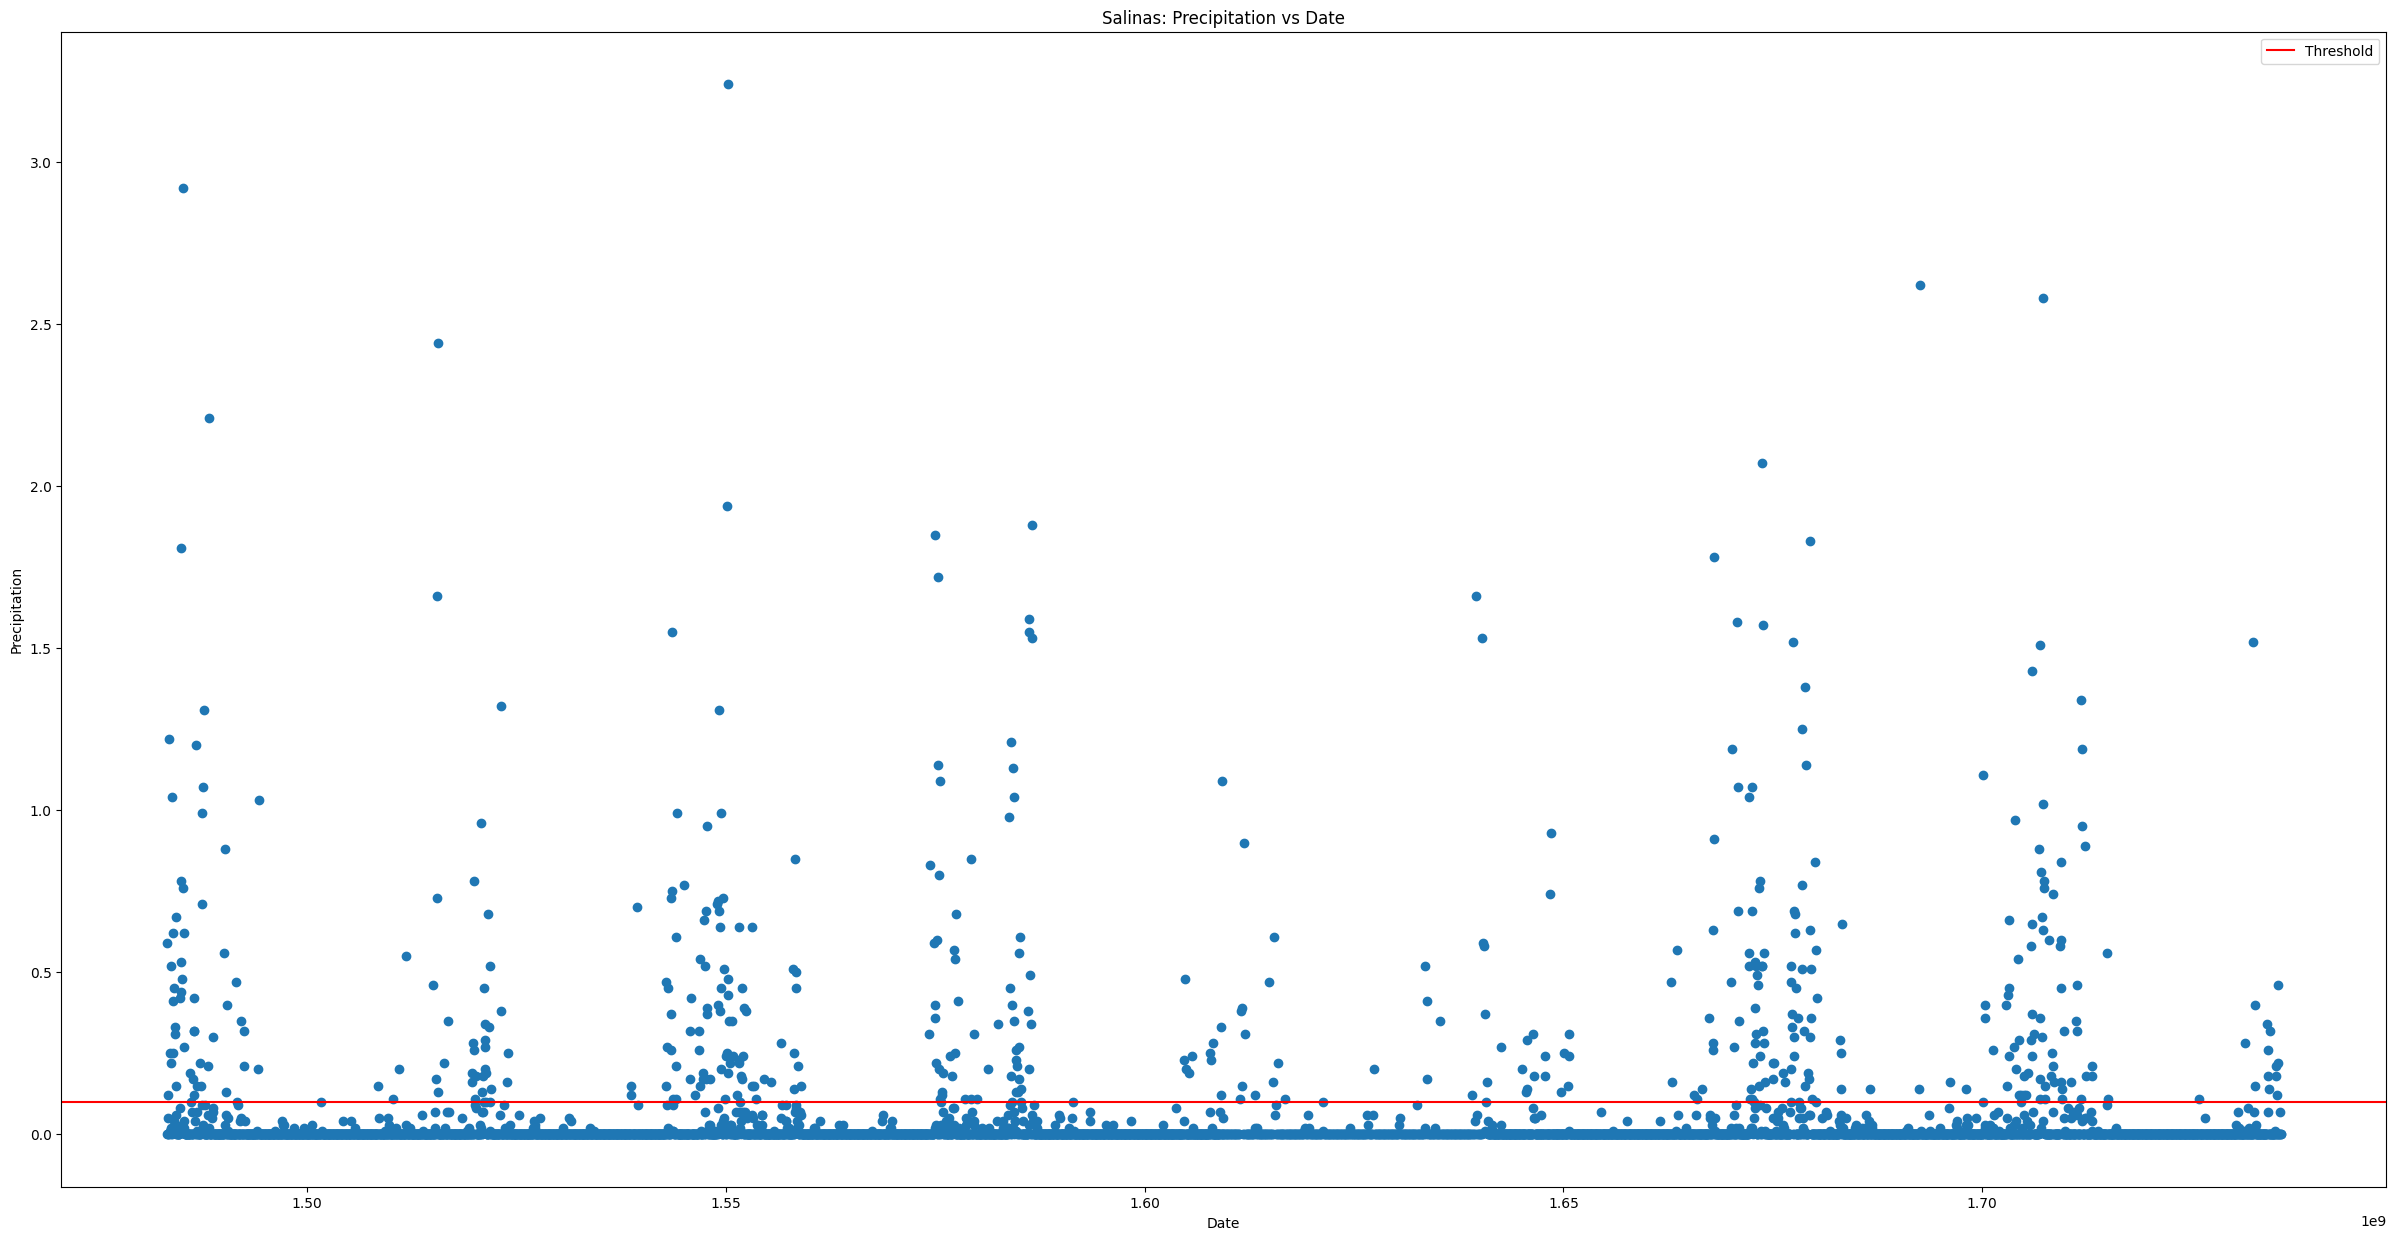

In [7]:
points =loc0.shape[0]
plt.figure(figsize=(30,15))
plt.axhline(0.1, color = "red", label = "Threshold")
plt.scatter(x = dates_float[0:points], y= loc0["ppt (inches)"][0:points])
plt.ylabel("Precipitation")
plt.xlabel("Date")
plt.legend()
plt.title("Salinas: Precipitation vs Date")
plt.savefig("Plots/Salinas_ppt_vs_date.png")
plt.show()

In [8]:
def plot_ppt(loc_start, loc_end):
    fig, axes= plt.subplots(figsize = (26,40), nrows= loc_end-loc_start, ncols=1)
    for i in range(loc_start, loc_end):
        loc0 = data[data["Name"] == f"Location {i+1}"]
        points = loc0.shape[0]
        axes[i-loc_start].axhline(0.1, color = "red")
        axes[i-loc_start].scatter(x = dates_float[0:points], y= loc0["ppt (inches)"][0:points])
        axes[i-loc_start].set_ylabel("Precipitation (ppt)")
        axes[i-loc_start].set_xlabel("Date (Julian Date)")
        axes[i-loc_start].set_title(f"Location: {i+1} Precipitation vs. Date (Julian Date)")
    plt.savefig(f"Plots/locations_{loc_start}_to_{loc_end}.png")
    plt.show()

In [9]:
lon = data["Longitude"]
lat = data["Latitude"]
size = len(lon)
data_coords = [(float(lat[i]), float(lon[i])) for i in range(size)]

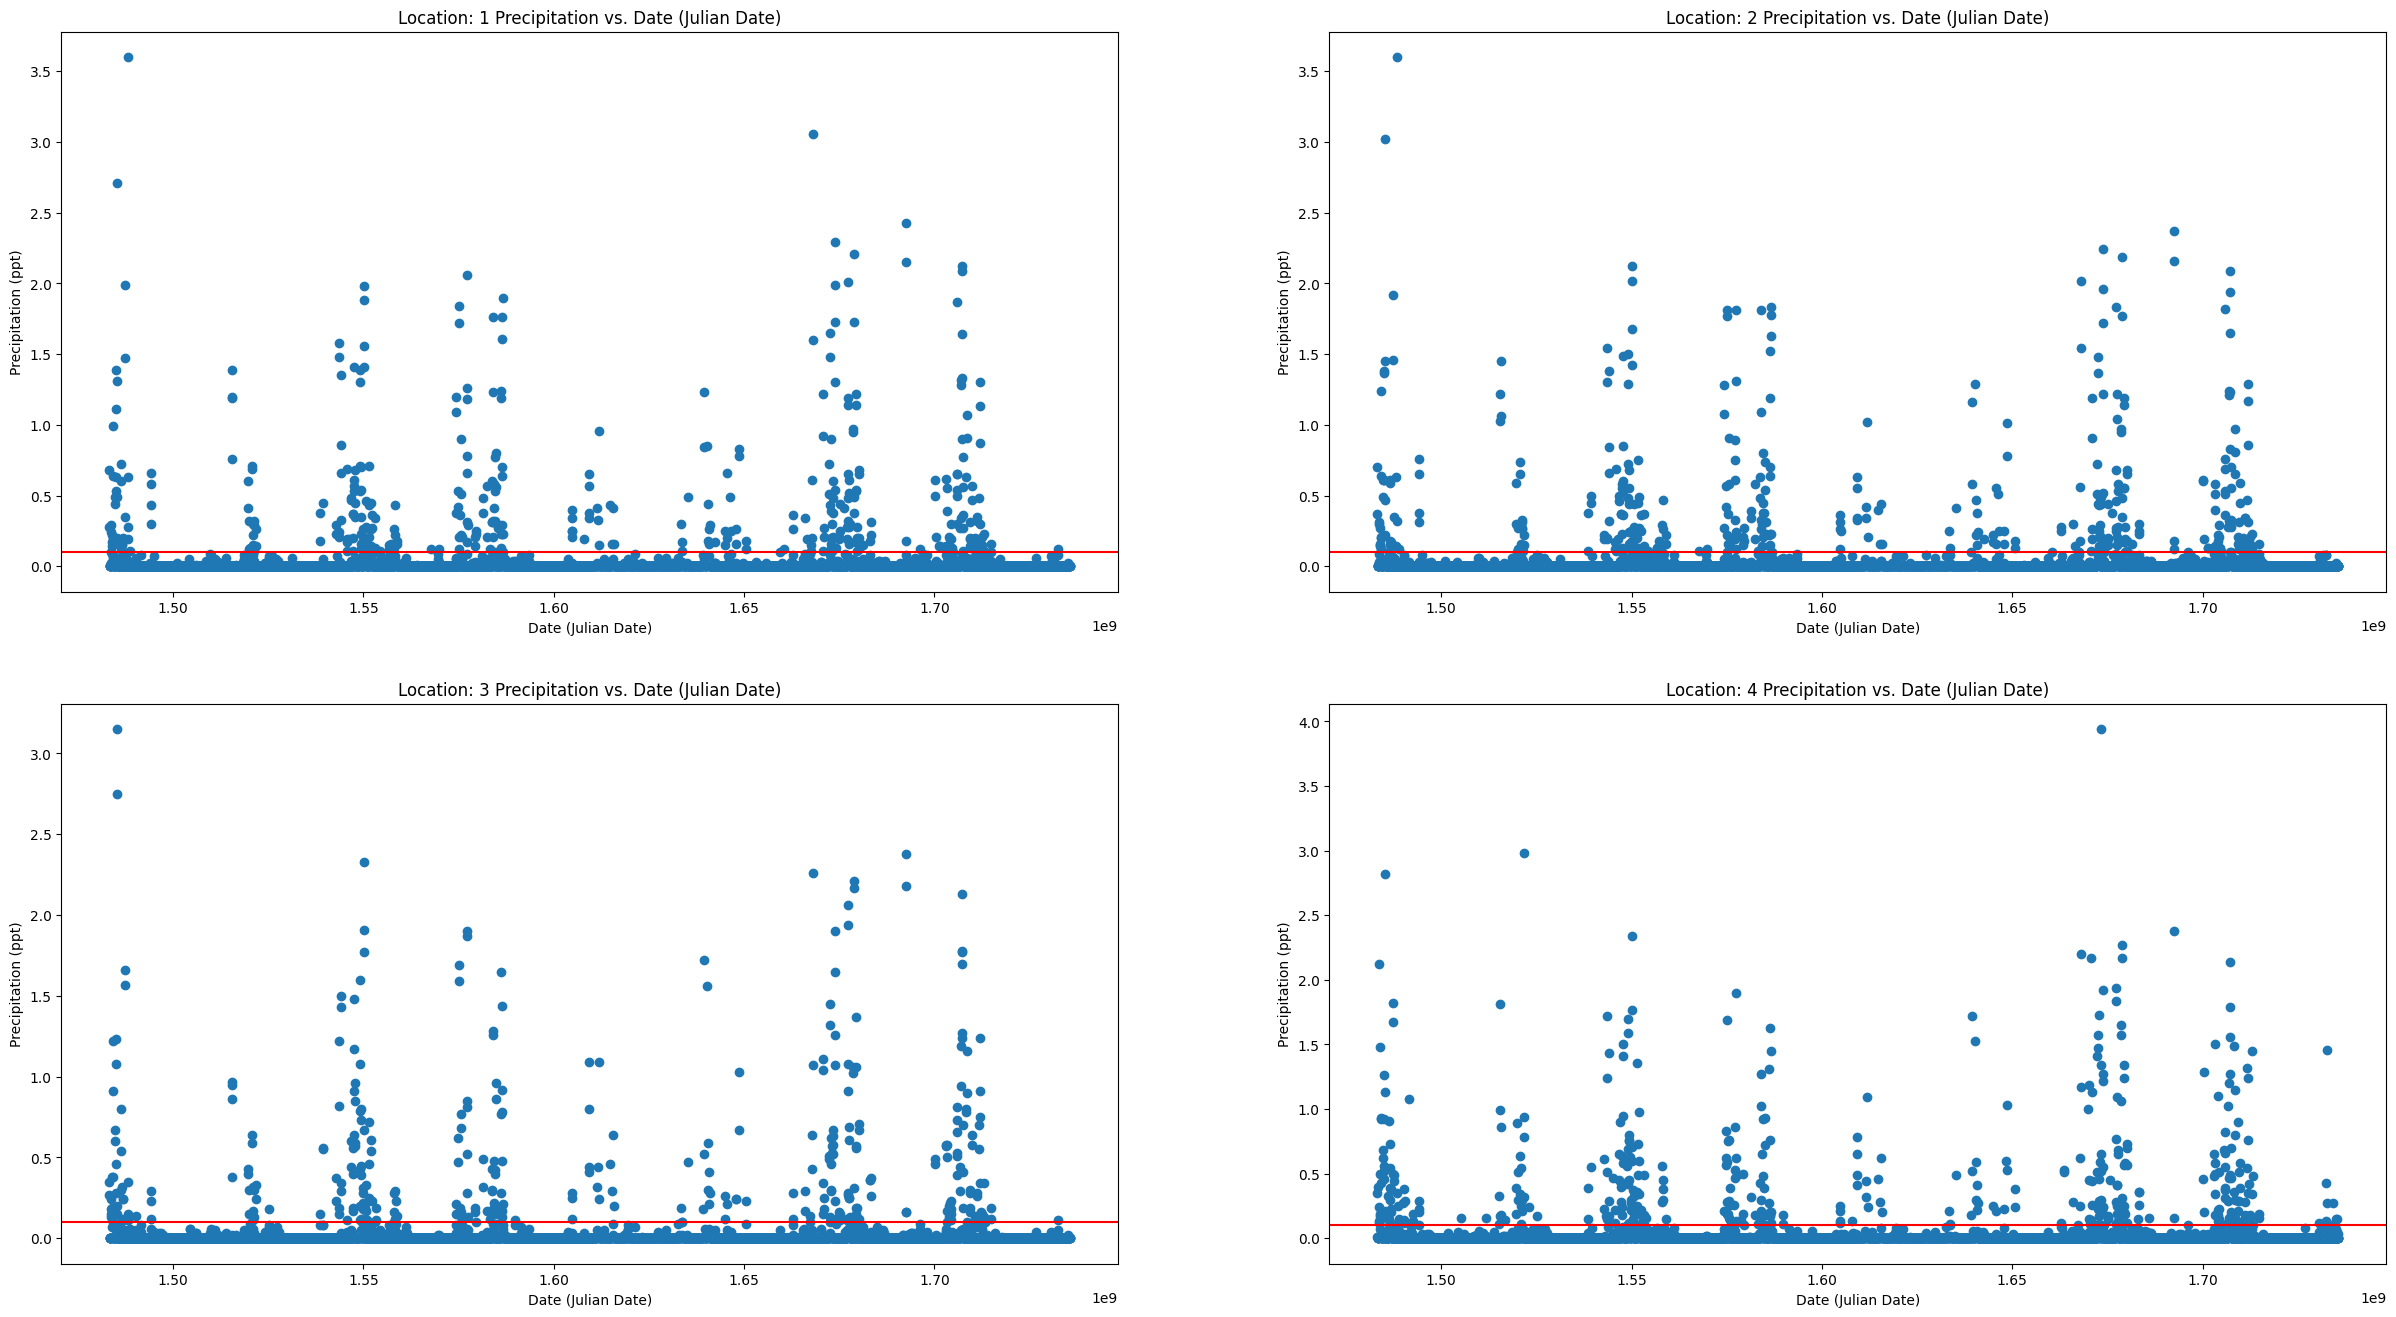

In [11]:
fig, axes= plt.subplots(figsize = (30,16), nrows= 2, ncols=2)
count = 1
for i in range(2):
    for j in range(2):
        loc0 = data[data["Name"] == f"Location {count}"]
        points = loc0.shape[0]
        axes[i][j].axhline(0.1, color = "red")
        axes[i][j].scatter(x = dates_float[0:points], y= loc0["ppt (inches)"][0:points])
        axes[i][j].set_ylabel("Precipitation (ppt)")
        axes[i][j].set_xlabel("Date (Julian Date)")
        axes[i][j].set_title(f"Location: {count} Precipitation vs. Date (Julian Date)")
        count += 1
plt.show()

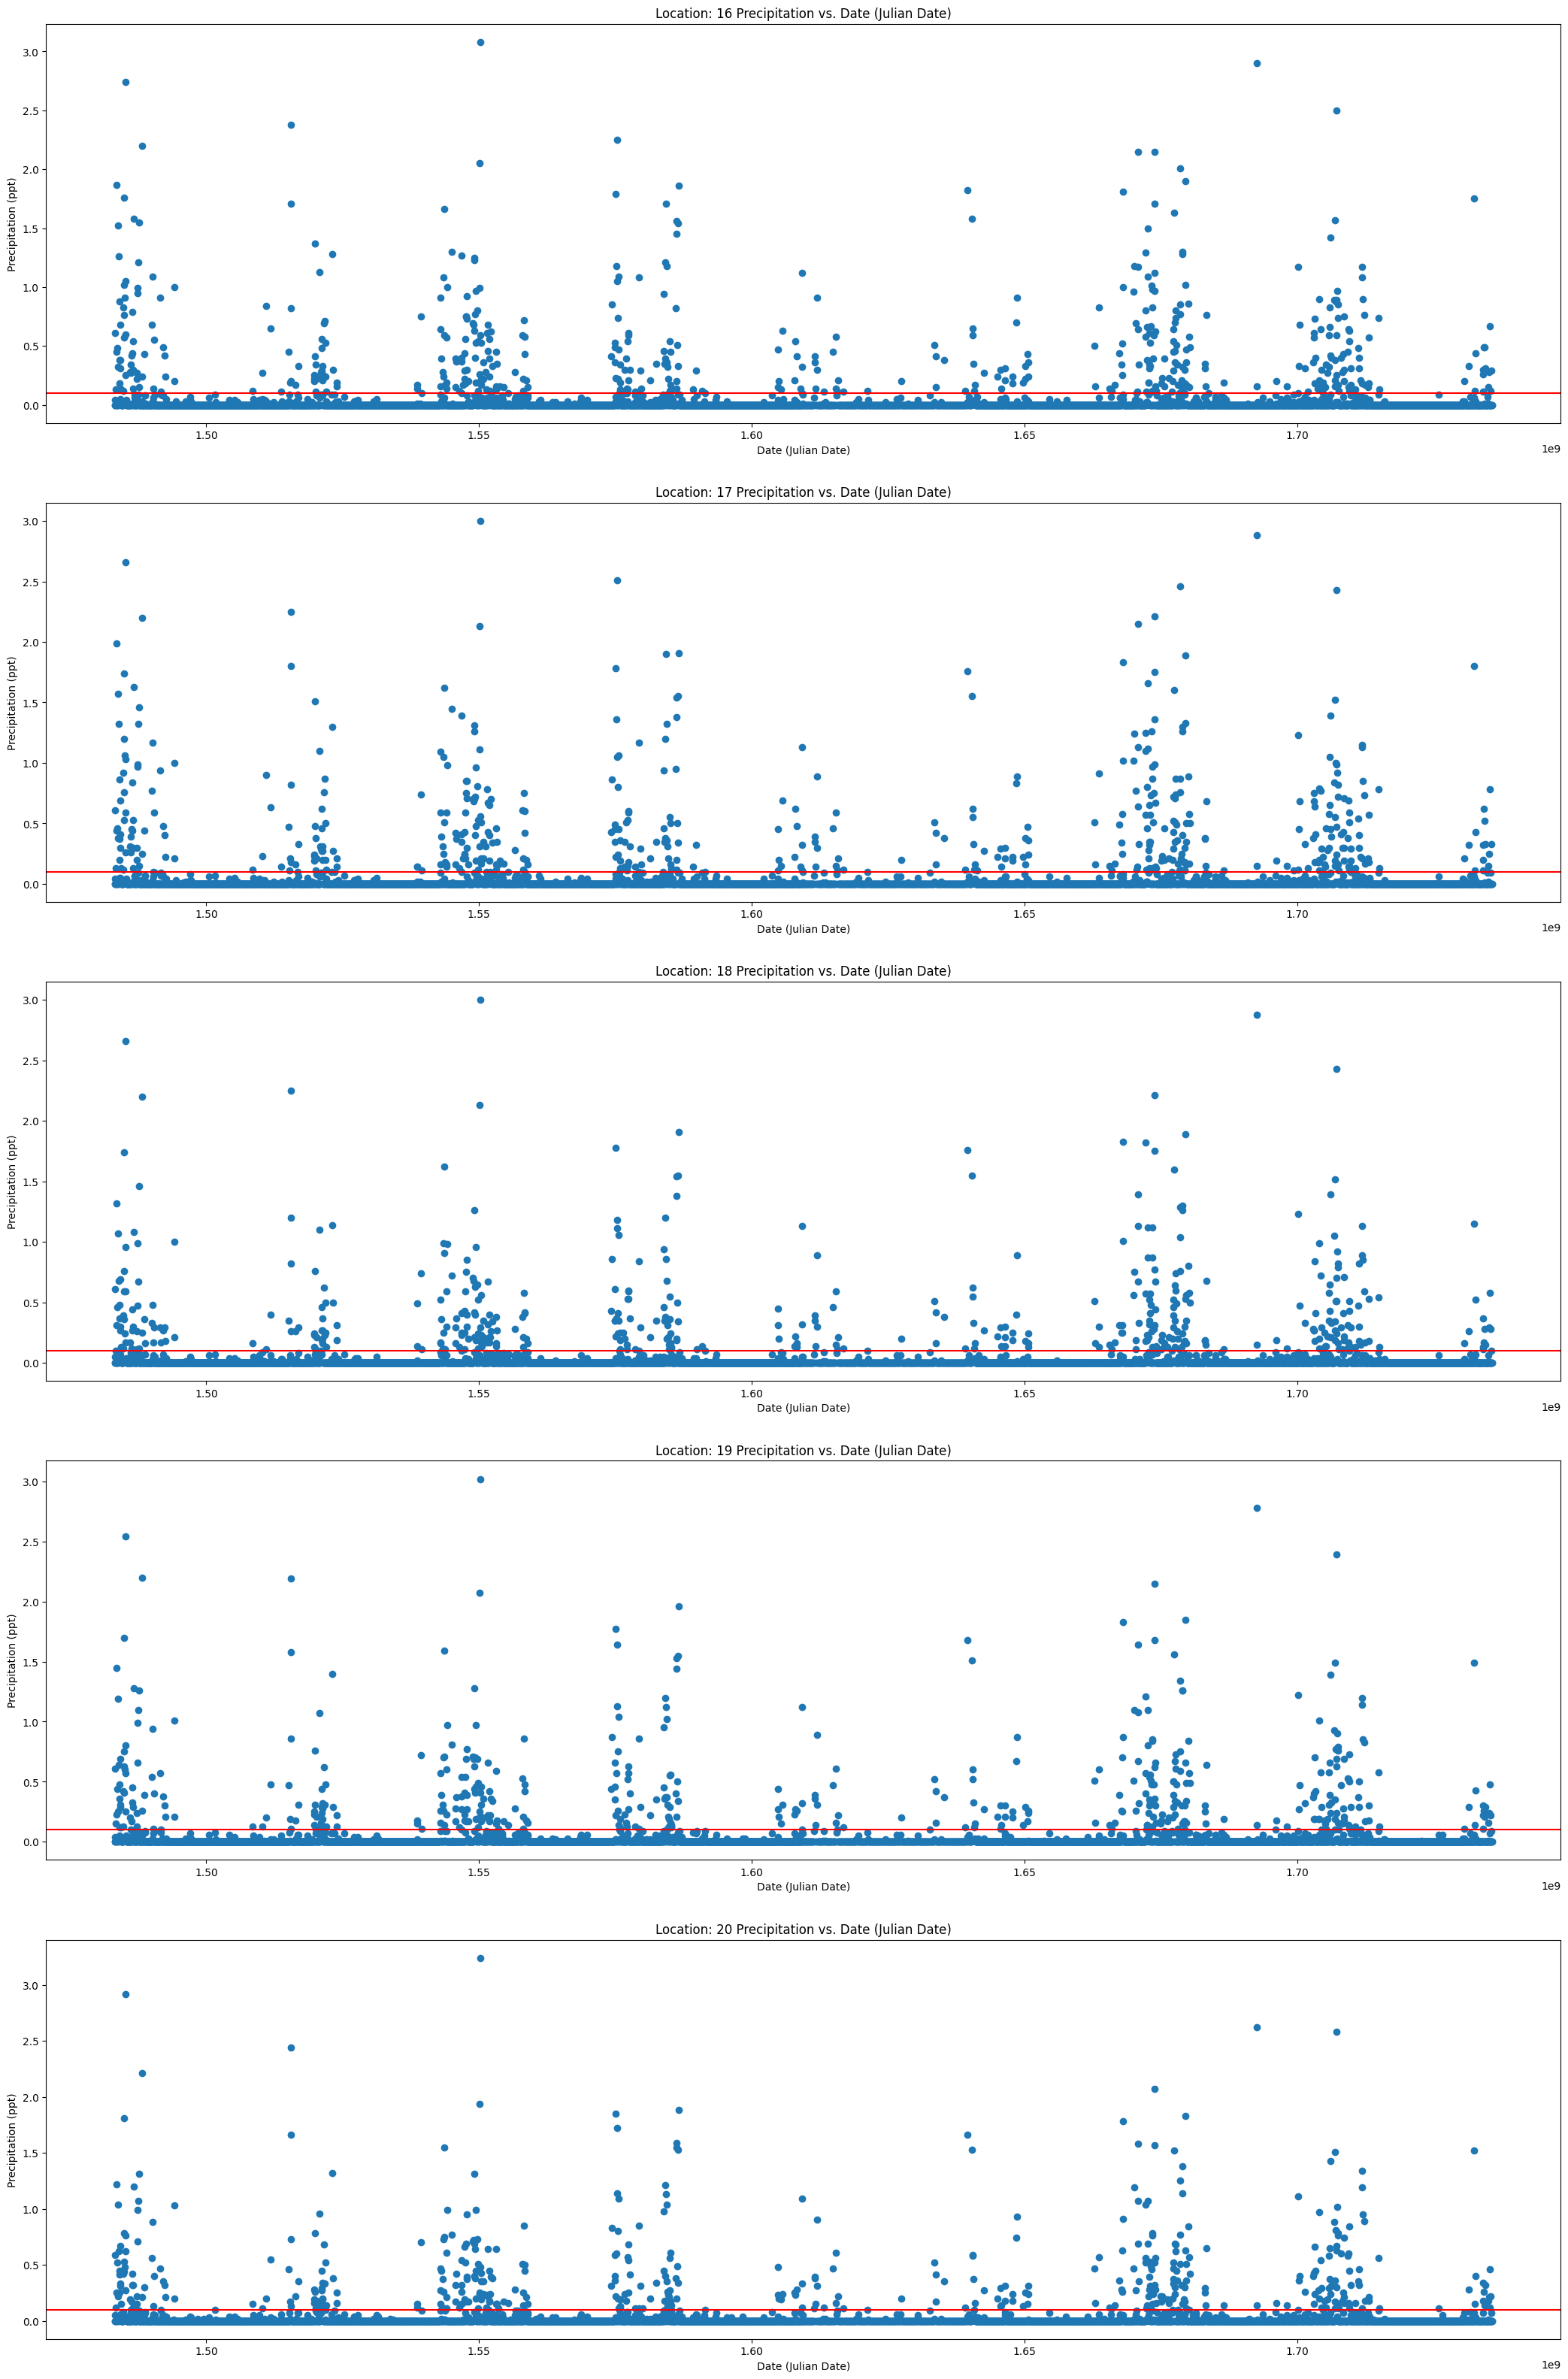

In [12]:
plot_ppt(15,20)

In [40]:
loc1 = data[data["Name"] == "Location 1"]
loc1["wet_period"] = loc1["ppt (inches)"] >= 0.1
loc1["wet_period"] = loc1["wet_period"].astype("int")

/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_48845/2057316130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loc1["wet_period"] = loc1["ppt (inches)"] >= 0.1
/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_48845/2057316130.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loc1["wet_period"] = loc1["wet_period"].astype("int")


In [64]:
def find_wet_dry_periods(loc1):
    loc1["wet_period"] = loc1["ppt (inches)"] >= 0.1
    loc1["wet_period"] = loc1["wet_period"].astype("int")
    date_wp = pd.DataFrame({
        "Location": loc1['Name'],
        "Date": pd.to_datetime(loc1["Date"]),
        "WetPeriod": loc1["wet_period"]
    }) 
    date_wp["group"] = (date_wp["WetPeriod"] != date_wp["WetPeriod"].shift()).cumsum() 
    periods = (
        date_wp.groupby("group")
        .agg(
            Start=("Date", "min"),
            End=("Date", "max"),
            Type=("WetPeriod", "first"),
            Location=("Location", "first") 
        )
        .reset_index(drop=True)
    )

    periods["Type"] = periods["Type"].map({1: "Wet", 0: "Dry"})
    periods = periods[["Location","Type", "Start", "End"]]
    periods["Duration"] =(periods["End"] - periods["Start"]).dt.days + 1
    return periods

In [72]:
output_data = []
for i in range(1,21):
    output_data+= [find_wet_dry_periods(data[data["Name"] == f"Location {i}"])]

/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_48845/1623305835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loc1["wet_period"] = loc1["ppt (inches)"] >= 0.1
/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_48845/1623305835.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loc1["wet_period"] = loc1["wet_period"].astype("int")
/var/folders/bg/5dmr_ymn0g7d0fqz7043vr8c0000gp/T/ipykernel_48845/1623305835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [77]:
output = pd.concat(output_data, ignore_index=True)

In [79]:
output.head(50)

,Location,Type,Start,End,Duration
0,Location 1,Wet,2017-01-01,2017-01-01,1
1,Location 1,Dry,2017-01-02,2017-01-05,4
2,Location 1,Wet,2017-01-06,2017-01-06,1
3,Location 1,Dry,2017-01-07,2017-01-09,3
4,Location 1,Wet,2017-01-10,2017-01-10,1
5,Location 1,Dry,2017-01-11,2017-01-11,1
6,Location 1,Wet,2017-01-12,2017-01-13,2
7,Location 1,Dry,2017-01-14,2017-01-18,5
8,Location 1,Wet,2017-01-19,2017-01-21,3
9,Location 1,Dry,2017-01-22,2017-01-22,1
